In [81]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [82]:
data = pd.read_csv("earthquake_1995-2023.csv")

print(data.head())
print(data.info())

                                      title  magnitude         date_time  cdi  \
0          M 6.5 - 42 km W of Sola, Vanuatu        6.5  16-08-2023 12:47    7   
1  M 6.5 - 43 km S of Intipucá, El Salvador        6.5  19-07-2023 00:22    8   
2  M 6.6 - 25 km ESE of Loncopué, Argentina        6.6  17-07-2023 03:05    7   
3     M 7.2 - 98 km S of Sand Point, Alaska        7.2  16-07-2023 06:48    6   
4                  M 7.3 - Alaska Peninsula        7.3  16-07-2023 06:48    0   

   mmi   alert  tsunami  sig net  nst      dmin    gap magType    depth  \
0    4   green        0  657  us  114  7.177000   25.0     mww  192.955   
1    6  yellow        0  775  us   92  0.679000   40.0     mww   69.727   
2    5   green        0  899  us   70  1.634000   28.0     mww  171.371   
3    6   green        1  860  us  173  0.907000   36.0     mww   32.571   
4    5     NaN        1  820  at   79  0.879451  172.8      Mi   21.000   

   latitude  longitude               location      continent  

In [83]:
data = data.drop_duplicates()
data = data.dropna()

In [84]:
print(data.columns)

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')


In [85]:
X = data[['magnitude','depth','latitude','longitude']]

In [86]:
def classify_risk(m):
    if m < 4:
        return "Low"
    elif m < 6:
        return "Medium"
    else:
        return "High"

In [87]:
data['risk_level'] = data['magnitude'].apply(classify_risk)

In [88]:
print(data[['magnitude','risk_level']].head())

    magnitude risk_level
2         6.6       High
17        6.5       High
18        7.0       High
19        6.5       High
20        6.5       High


In [89]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['risk_level'] = encoder.fit_transform(data['risk_level'])

In [90]:
X = data[['magnitude','depth','latitude','longitude']]
y = data['risk_level']

In [91]:
print(data.columns)

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country', 'risk_level'],
      dtype='object')


In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [93]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
print(data['risk_level'].value_counts())

risk_level
0    106
Name: count, dtype: int64


In [95]:
def classify_risk(m):
    if m < 6.5:
        return "Low"
    elif m < 7.0:
        return "Medium"
    else:
        return "High"

In [96]:
data['risk_level'] = data['magnitude'].apply(classify_risk)

In [97]:
print(data['risk_level'].value_counts())

risk_level
Medium    62
High      44
Name: count, dtype: int64


In [98]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['risk_level'] = encoder.fit_transform(data['risk_level'])

In [99]:
X = data[['magnitude','depth','latitude','longitude']]
y = data['risk_level']

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [100]:
print(data[['magnitude','risk_level']].head())
print(data['risk_level'].value_counts())

    magnitude  risk_level
2         6.6           1
17        6.5           1
18        7.0           0
19        6.5           1
20        6.5           1
risk_level
1    62
0    44
Name: count, dtype: int64


In [101]:
print(data.columns)
print(data.head())
print(data['risk_level'].value_counts())

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country', 'risk_level'],
      dtype='object')
                                                title  magnitude  \
2            M 6.6 - 25 km ESE of Loncopué, Argentina        6.6   
17  M 6.5 - near the east coast of the Kamchatka P...        6.5   
18               M 7.0 - New Guinea, Papua New Guinea        7.0   
19  M 6.5 - 84 km NNW of San Antonio de los Cobres...        6.5   
20             M 6.5 - 40 km SSE of Jurm, Afghanistan        6.5   

           date_time  cdi  mmi   alert  tsunami   sig net  nst   dmin   gap  \
2   17-07-2023 03:05    7    5   green        0   899  us   70  1.634  28.0   
17  03-04-2023 03:06    7    6  yellow        1   655  us  104  0.266  30.0   
18  02-04-2023 18:04    7    7   green        1   781  us  105  6.450  31.0   
19  22-03-2023 16:00    4    4 

In [102]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.9090909090909091


In [103]:
tree_model = DecisionTreeClassifier()

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 1.0


In [104]:
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


In [105]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 1.0


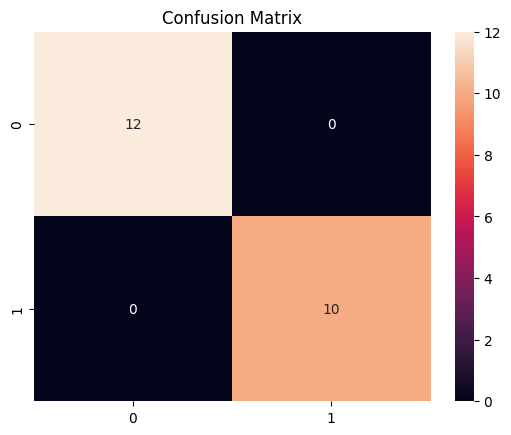

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()